In [1]:
import torch
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

# Import dataset from PyTorch Geometric
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

# Print information
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print first element
print(f'Graph: {dataset[0]}')

/home/filipe-silva/redes_grafos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cora()
------------
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [3]:
data = dataset[0]

print(f'x = {data.x.shape}')
print(data.x)

x = torch.Size([2708, 1433])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [4]:
print(f'edge_index = {data.edge_index.shape}')
print(data.edge_index)

edge_index = torch.Size([2, 10556])
tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])


In [5]:
from torch_geometric.utils import to_dense_adj

A = to_dense_adj(data.edge_index)[0].numpy().astype(int)
print(f'A = {A.shape}')
print(A)

A = (2708, 2708)
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]]


In [6]:
print(f'y = {data.y.shape}')
print(data.y)

y = torch.Size([2708])
tensor([3, 4, 4,  ..., 3, 3, 3])


In [7]:
print(f'train_mask = {data.train_mask.shape}')
print(data.train_mask)

train_mask = torch.Size([2708])
tensor([ True,  True,  True,  ..., False, False, False])


In [8]:
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Edges are directed: False
Graph has isolated nodes: False
Graph has loops: False


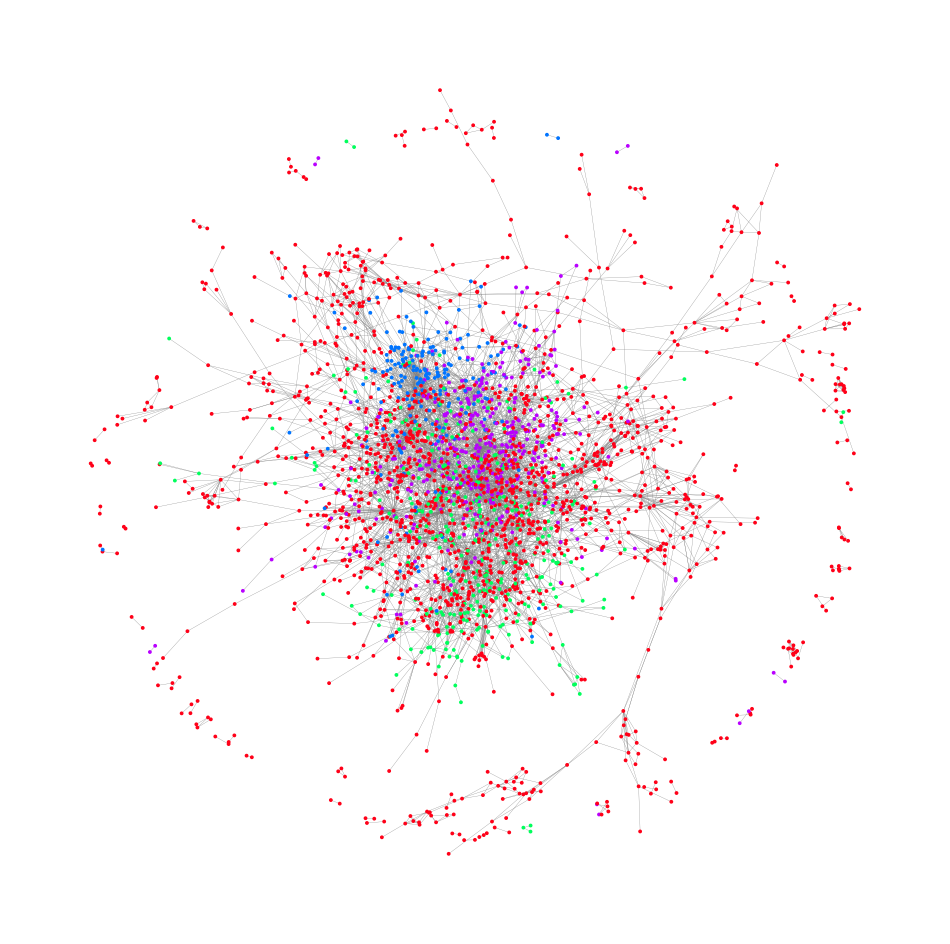

In [9]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=False,
                node_size=3,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.2,
                edge_color="grey",
                font_size=0
                )
plt.show()

In [10]:
from torch_geometric.nn import DenseGCNConv
from torch.nn import Linear
import torch.nn.functional as F

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = DenseGCNConv(dataset.num_features, 16) 
        self.gcn2 = DenseGCNConv(16, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.gcn1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.7, training=self.training)
        x = self.gcn2(x, edge_index)
        return x

model = GCN()
print(model)

GCN(
  (gcn1): DenseGCNConv(1433, 16)
  (gcn2): DenseGCNConv(16, 7)
)


In [12]:
x_dense = data.x.unsqueeze(0)
adj = to_dense_adj(data.edge_index)

# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

def train(model,optimizer,criterion):# Training loop
    
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out = model(x_dense, adj)
    out = out.squeeze(0)
    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out.argmax(dim=1)[data.train_mask], data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    return loss.item(), acc.item()

def evaluate(model,criterion):# Validation loop
    model.eval() 
    with torch.no_grad(): 
        out_val = model(x_dense, adj)
        out_val = out_val.squeeze(0)
        val_loss = criterion(out_val[data.val_mask], data.y[data.val_mask])
        out_val = out_val.argmax(dim=1)
        val_correct = out_val[data.val_mask] == data.y[data.val_mask]
        val_acc = int(val_correct.sum()) / int(data.val_mask.sum())
    return val_loss.item(),val_acc


In [ ]:
model_gcn = GCN()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01,weight_decay=5e-4)

train_losses = []
val_losses = []

for epoch in range(250):
    loss , acc = train(model_gcn, optimizer, criterion)
    
    val_los, val_acc= evaluate(model_gcn,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | Acc: {acc*100:.2f}%')

Epoch   0 | Loss: 1.95 | ValLoss: 1.95 | Acc: 11.43%
Epoch  10 | Loss: 1.85 | ValLoss: 1.88 | Acc: 57.14%
Epoch  20 | Loss: 1.72 | ValLoss: 1.81 | Acc: 63.57%
Epoch  30 | Loss: 1.53 | ValLoss: 1.70 | Acc: 75.71%
Epoch  40 | Loss: 1.38 | ValLoss: 1.59 | Acc: 80.00%
Epoch  50 | Loss: 1.22 | ValLoss: 1.47 | Acc: 85.00%
Epoch  60 | Loss: 1.06 | ValLoss: 1.35 | Acc: 82.14%
Epoch  70 | Loss: 0.92 | ValLoss: 1.26 | Acc: 87.14%
Epoch  80 | Loss: 0.83 | ValLoss: 1.19 | Acc: 85.71%
Epoch  90 | Loss: 0.79 | ValLoss: 1.13 | Acc: 88.57%
Epoch 100 | Loss: 0.68 | ValLoss: 1.06 | Acc: 92.14%
Epoch 110 | Loss: 0.64 | ValLoss: 1.03 | Acc: 92.14%
Epoch 120 | Loss: 0.61 | ValLoss: 1.00 | Acc: 87.86%
Epoch 130 | Loss: 0.57 | ValLoss: 0.97 | Acc: 91.43%
Epoch 140 | Loss: 0.52 | ValLoss: 0.94 | Acc: 95.71%
Epoch 150 | Loss: 0.53 | ValLoss: 0.92 | Acc: 91.43%
Epoch 160 | Loss: 0.51 | ValLoss: 0.90 | Acc: 89.29%
Epoch 170 | Loss: 0.48 | ValLoss: 0.89 | Acc: 93.57%
Epoch 180 | Loss: 0.50 | ValLoss: 0.87 | Acc: 

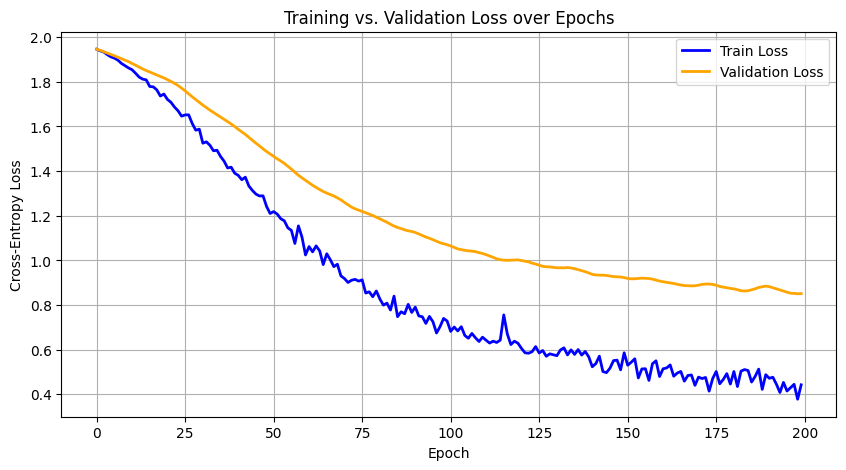

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:

def test(model):
    model.eval()
    out = model(x_dense, adj)
    out = out.squeeze(0)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

test_acc = test(model_gcn)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8100


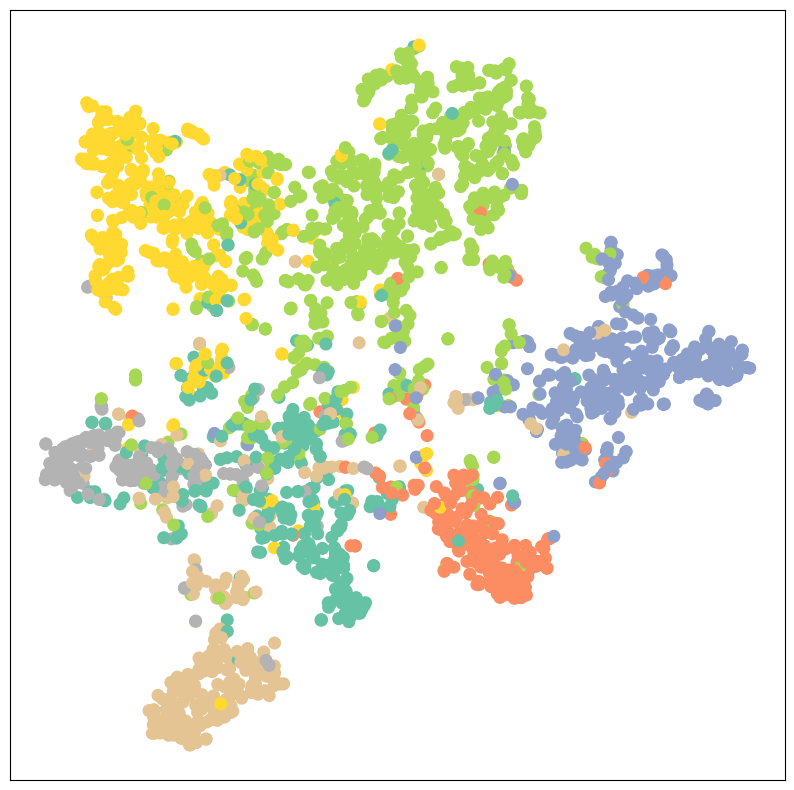

In [ ]:
model_gcn.eval()
out = model_gcn(data.x, data.edge_index)
visualize(out, color=data.y)

## GAT CONV ##

In [ ]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GATConv(dataset.num_features, 8, heads=8,dropout=0.6) 
        self.gat2 = GATConv(8*8, dataset.num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

model = GAT()
print(model)


GAT(
  (gat1): GATConv(1433, 8, heads=8)
  (gat2): GATConv(64, 7, heads=1)
)


In [ ]:
import copy

model_gat = GAT()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    dict(params=model_gat.gat1.parameters(), weight_decay=5e-4),
    dict(params=model_gat.gat2.parameters(), weight_decay=0)   
], lr=0.005)

train_losses = []
val_losses = []

best_val_acc = 0.0
best_weights = None
best_epoch = 0

for epoch in range(250):
    loss , acc = train(model_gat, optimizer, criterion)
    
    val_los, val_acc = evaluate(model_gat,criterion)
    
    train_losses.append(loss)
    val_losses.append(val_los)  
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model_gat.state_dict())
        best_epoch = epoch
        
    if epoch % 10 == 0:
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | ValLoss: {val_los:.2f} | Acc: {acc*100:.2f}%')
        

model_gat.load_state_dict(best_weights)
print(f'Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}')

Epoch   0 | Loss: 1.94 | ValLoss: 1.95 | Acc: 14.29%
Epoch  10 | Loss: 1.87 | ValLoss: 1.90 | Acc: 55.71%
Epoch  20 | Loss: 1.78 | ValLoss: 1.85 | Acc: 67.14%
Epoch  30 | Loss: 1.65 | ValLoss: 1.76 | Acc: 75.00%
Epoch  40 | Loss: 1.53 | ValLoss: 1.66 | Acc: 78.57%
Epoch  50 | Loss: 1.39 | ValLoss: 1.55 | Acc: 76.43%
Epoch  60 | Loss: 1.23 | ValLoss: 1.44 | Acc: 79.29%
Epoch  70 | Loss: 1.05 | ValLoss: 1.34 | Acc: 80.71%
Epoch  80 | Loss: 1.09 | ValLoss: 1.24 | Acc: 79.29%
Epoch  90 | Loss: 1.03 | ValLoss: 1.18 | Acc: 78.57%
Epoch 100 | Loss: 0.94 | ValLoss: 1.12 | Acc: 78.57%
Epoch 110 | Loss: 0.86 | ValLoss: 1.07 | Acc: 82.86%
Epoch 120 | Loss: 0.98 | ValLoss: 1.03 | Acc: 73.57%
Epoch 130 | Loss: 0.95 | ValLoss: 0.99 | Acc: 76.43%
Epoch 140 | Loss: 0.87 | ValLoss: 0.96 | Acc: 81.43%
Epoch 150 | Loss: 0.75 | ValLoss: 0.92 | Acc: 84.29%
Epoch 160 | Loss: 0.76 | ValLoss: 0.91 | Acc: 84.29%
Epoch 170 | Loss: 0.83 | ValLoss: 0.89 | Acc: 77.86%
Epoch 180 | Loss: 0.67 | ValLoss: 0.86 | Acc: 

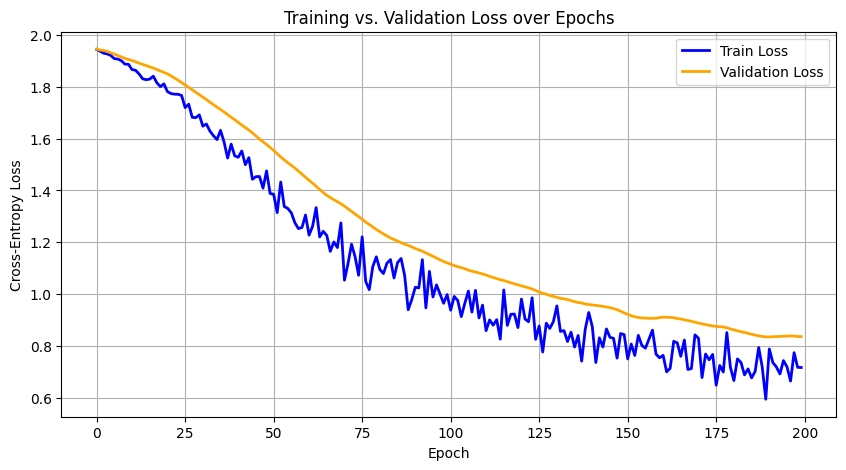

In [109]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [98]:
test_acc = test(model_gat)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8280


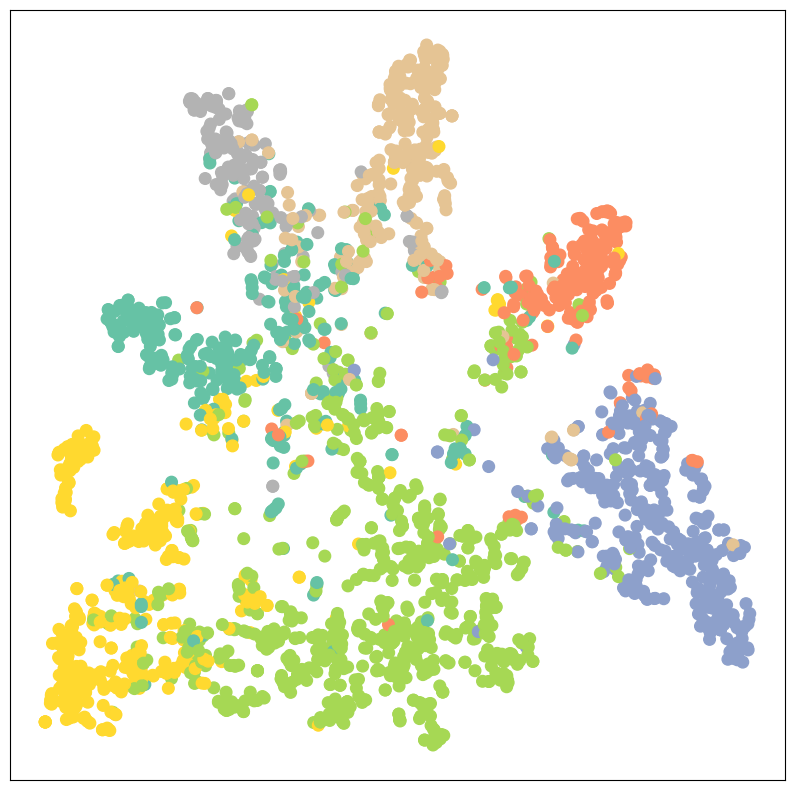

In [104]:
model_gat.eval()

out = model_gat(data.x, data.edge_index)
visualize(out, color=data.y)